In [1]:
import pandas as pd
from datetime import date, timedelta
import missingno as msno
import plotly.express as px
import sys

import random
import numpy as np

import sys

sys.path.insert(0, "../../utils")

from plots import *
from string_handling import *
from modules import *

enc = 'utf-8' 

random.seed(0)
np.random.seed(0)

pd.set_option('display.max_columns', None)

In [2]:
REGION = 'ExtNord'
YEARS = range(2015, 2026)

In [3]:
datasets = []

for YEAR in YEARS:
    print(f"Reading data for Cameroon {REGION} in {YEAR}")
    # Load the dataset for the specified year
    datasets.append(pd.read_csv(f'../../data/{REGION}/CM_{REGION}_Dataset_X_{YEAR}.csv', encoding=enc))

# Concatenate all datasets into a single DataFrame
df = pd.concat(datasets, ignore_index=True)

try:
    df.drop(['Unnamed: 0'], axis=1, inplace=True)
except KeyError:
    print("Column 'Unnamed: 0' not found in the DataFrame.")

Reading data for Cameroon ExtNord in 2015
Reading data for Cameroon ExtNord in 2016
Reading data for Cameroon ExtNord in 2017
Reading data for Cameroon ExtNord in 2018
Reading data for Cameroon ExtNord in 2019
Reading data for Cameroon ExtNord in 2020
Reading data for Cameroon ExtNord in 2021
Reading data for Cameroon ExtNord in 2022
Reading data for Cameroon ExtNord in 2023
Reading data for Cameroon ExtNord in 2024
Reading data for Cameroon ExtNord in 2025


In [4]:
print(df.shape)

df.head()

(41210, 76)


,dt_placement,year,month,year_lc,month_sin,month_cos,GID0,GID1,GID2,GID3,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,rainfall,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,year_biovars,dt_weather_acc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lst_min_prev_month,lst_max_prev_month,rainfall_acc_prev_month
0,2015-01,2015,1,2014,0.5,0.866,extreme nord,diamare,bogo,balaza,14.515776,10.786560,0.193720,-0.107755,-0.368326,0.107755,0.194397,-0.106597,-0.366073,0.106597,0.012763,0.014083,0.014467,0.014083,25.68,34.58,16.78,0.0,39276.65,1226.36,1.93,150.78,348.81,179.77,0.0,4.88,8546.38,700.05,1.44,17.48,12.99,0.22,0.0,11.33,31,36.0,30,12,12,1,6,7,2014,2014-12,30.67,24.83,63.68,276.61,53.0,14.0,39.0,29.17,29.33,34.33,28.83,1345.0,483.0,0.0,143.14,1072.0,0.0,85.0,911.0,16.01,43.30,0.0707
1,2015-01,2015,1,2014,0.5,0.866,extreme nord,diamare,bogo,balda,14.724237,10.914551,0.168083,-0.119696,-0.352593,0.119696,0.169689,-0.117560,-0.351610,0.117560,0.010680,0.011892,0.011157,0.011892,26.24,35.49,16.99,0.0,18291.64,963.16,2.62,156.14,318.51,179.90,0.0,132.00,4472.68,795.26,1.50,10.59,7.15,0.17,0.0,326.39,31,36.0,30,12,12,1,6,7,2014,2014-12,31.54,26.42,64.43,304.11,54.0,13.0,41.0,29.67,29.83,35.00,29.33,1228.0,422.0,0.0,140.46,982.0,0.0,91.0,784.0,16.36,45.76,0.1057
2,2015-01,2015,1,2014,0.5,0.866,extreme nord,diamare,bogo,bogo,14.597860,10.743440,0.186568,-0.100576,-0.358255,0.100576,0.189237,-0.099525,-0.362545,0.099525,0.010527,0.008578,0.009904,0.008578,25.53,34.59,16.48,0.0,31538.78,677.10,4.25,161.02,341.31,179.70,0.0,18.34,2223.42,767.99,1.50,12.02,3.33,0.22,0.0,11.73,31,36.0,30,12,12,1,6,7,2014,2014-12,30.08,24.83,63.68,292.20,52.0,13.0,39.0,27.83,29.17,34.17,27.33,1324.0,475.0,0.0,144.61,1070.0,0.0,74.0,701.0,16.29,43.22,0.0725
3,2015-01,2015,1,2014,0.5,0.866,extreme nord,diamare,bogo,borai,14.606980,10.653607,0.192535,-0.110211,-0.365544,0.110211,0.191105,-0.111085,-0.367493,0.111085,0.008786,0.009590,0.011213,0.009590,25.28,33.81,16.75,0.0,35412.34,801.73,2.50,156.39,340.98,179.71,0.0,32.70,3693.13,560.29,1.52,9.36,2.91,0.19,0.0,63.23,31,36.0,30,12,12,1,6,7,2014,2014-12,29.92,24.33,60.83,282.71,52.0,12.0,40.0,27.83,28.83,33.83,27.00,1301.0,476.0,0.0,144.58,1048.0,0.0,63.0,693.0,16.75,42.51,0.0133
4,2015-01,2015,1,2014,0.5,0.866,extreme nord,diamare,bogo,guinggley,14.702740,10.792848,0.184092,-0.100503,-0.358690,0.100503,0.181272,-0.101963,-0.357540,0.101963,0.012842,0.013507,0.011516,0.013507,25.77,35.01,16.52,0.0,18966.68,1323.61,2.50,157.37,326.72,179.91,0.0,251.95,5392.49,784.41,1.20,5.78,5.71,0.12,0.0,705.96,31,36.0,30,12,12,1,6,7,2014,2014-12,30.71,25.08,64.32,279.17,53.0,14.0,39.0,28.17,29.50,34.17,28.17,1268.0,440.0,0.0,142.37,1023.0,0.0,180.0,1023.0,16.63,44.81,0.1475


Text(0.5, 1.0, 'Years: 2015 - 2025')

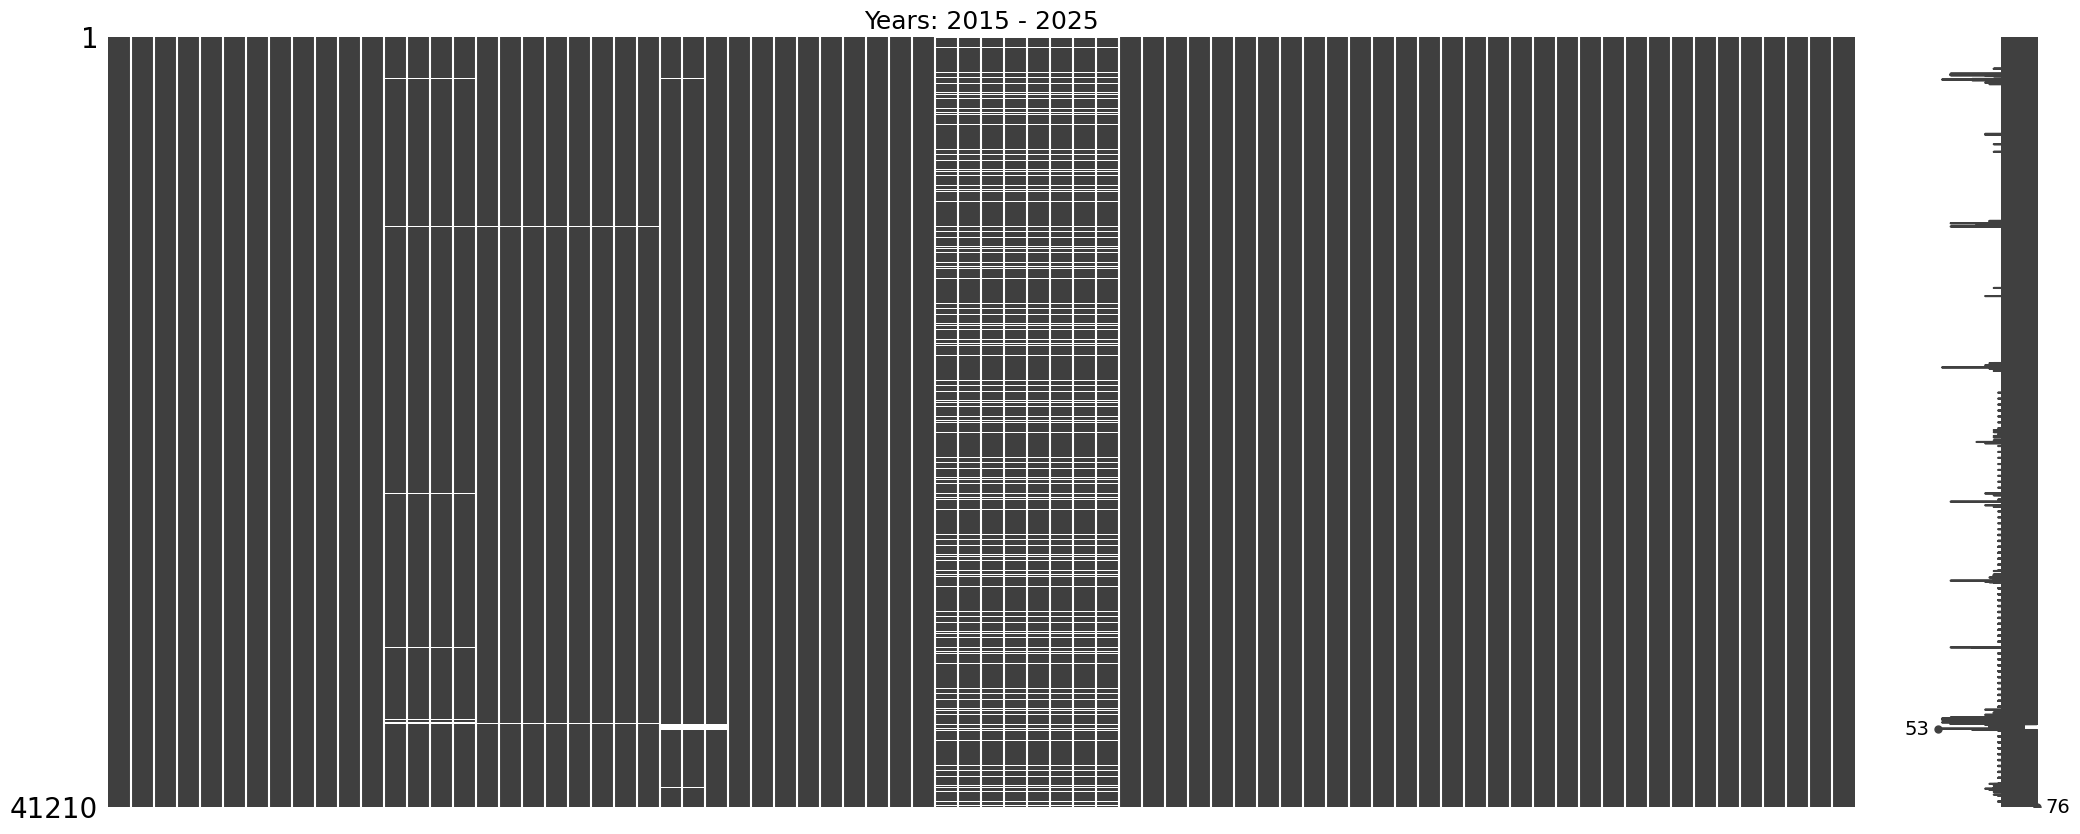

In [5]:
msno.matrix(df, label_rotation=90)
ax = plt.gca()
ax.set_title(f"Years: {min(YEARS)} - {max(YEARS)}", fontsize=18)

In [6]:
df['dt_placement'] = pd.to_datetime(df['dt_placement']).dt.to_period('M')
df['dt_weather_acc'] = pd.to_datetime(df['dt_weather_acc']).dt.to_period('M')
df.rename(columns={'dt_placement': 'dt_prediction'}, inplace=True)
df['location'] = list(zip(df['GID0'], df['GID2'], df['GID3']))

In [7]:
dataset_final = df.copy()

In [8]:
len(dataset_final.columns.to_list())


77

In [9]:
rearranged_columns = ['location','GID0','GID1','GID2','GID3','x','y',
 'dt_prediction','year', 'month','month_sin','month_cos', 'dt_weather_acc', 'year_biovars', 'year_lc',
 'ndvi','ndmi','ndwi','ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std','ndmi_std','ndwi_std','ndbi_std',
 'lst','lst_day','lst_night','lst_min_prev_month','lst_max_prev_month',
 'rainfall','rainfall_acc_prev_month',
 'distance_to_coast','distance_to_river','slope_mean_1km','aspect_mean_200m','elevation_mean_1km','hillshade_mean_1km','fs_area_1km','flow_accu_200m',
 'distance_to_coast_std','distance_to_river_std','slope_mean_1km_std','aspect_mean_200m_std','elevation_mean_1km_std','hillshade_mean_1km_std','fs_area_1km_std','flow_accu_200m_std',
 'lc_prop1','lc_prop2','lc_prop3','lc_type1','lc_type2','lc_type3','lc_type4','lc_type5',
 'bio1','bio2','bio3','bio4','bio5','bio6','bio7','bio8','bio9','bio10','bio11','bio12','bio13','bio14','bio15','bio16','bio17','bio18','bio19']

In [10]:
dataset_final= dataset_final[rearranged_columns].copy()

In [11]:
dataset_final.head()

,location,GID0,GID1,GID2,GID3,x,y,dt_prediction,year,month,month_sin,month_cos,dt_weather_acc,year_biovars,year_lc,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_min_prev_month,lst_max_prev_month,rainfall,rainfall_acc_prev_month,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,"(extreme nord, bogo, balaza)",extreme nord,diamare,bogo,balaza,14.515776,10.786560,2015-01,2015,1,0.5,0.866,2014-12,2014,2014,0.193720,-0.107755,-0.368326,0.107755,0.194397,-0.106597,-0.366073,0.106597,0.012763,0.014083,0.014467,0.014083,25.68,34.58,16.78,16.01,43.30,0.0,0.0707,39276.65,1226.36,1.93,150.78,348.81,179.77,0.0,4.88,8546.38,700.05,1.44,17.48,12.99,0.22,0.0,11.33,31,36.0,30,12,12,1,6,7,30.67,24.83,63.68,276.61,53.0,14.0,39.0,29.17,29.33,34.33,28.83,1345.0,483.0,0.0,143.14,1072.0,0.0,85.0,911.0
1,"(extreme nord, bogo, balda)",extreme nord,diamare,bogo,balda,14.724237,10.914551,2015-01,2015,1,0.5,0.866,2014-12,2014,2014,0.168083,-0.119696,-0.352593,0.119696,0.169689,-0.117560,-0.351610,0.117560,0.010680,0.011892,0.011157,0.011892,26.24,35.49,16.99,16.36,45.76,0.0,0.1057,18291.64,963.16,2.62,156.14,318.51,179.90,0.0,132.00,4472.68,795.26,1.50,10.59,7.15,0.17,0.0,326.39,31,36.0,30,12,12,1,6,7,31.54,26.42,64.43,304.11,54.0,13.0,41.0,29.67,29.83,35.00,29.33,1228.0,422.0,0.0,140.46,982.0,0.0,91.0,784.0
2,"(extreme nord, bogo, bogo)",extreme nord,diamare,bogo,bogo,14.597860,10.743440,2015-01,2015,1,0.5,0.866,2014-12,2014,2014,0.186568,-0.100576,-0.358255,0.100576,0.189237,-0.099525,-0.362545,0.099525,0.010527,0.008578,0.009904,0.008578,25.53,34.59,16.48,16.29,43.22,0.0,0.0725,31538.78,677.10,4.25,161.02,341.31,179.70,0.0,18.34,2223.42,767.99,1.50,12.02,3.33,0.22,0.0,11.73,31,36.0,30,12,12,1,6,7,30.08,24.83,63.68,292.20,52.0,13.0,39.0,27.83,29.17,34.17,27.33,1324.0,475.0,0.0,144.61,1070.0,0.0,74.0,701.0
3,"(extreme nord, bogo, borai)",extreme nord,diamare,bogo,borai,14.606980,10.653607,2015-01,2015,1,0.5,0.866,2014-12,2014,2014,0.192535,-0.110211,-0.365544,0.110211,0.191105,-0.111085,-0.367493,0.111085,0.008786,0.009590,0.011213,0.009590,25.28,33.81,16.75,16.75,42.51,0.0,0.0133,35412.34,801.73,2.50,156.39,340.98,179.71,0.0,32.70,3693.13,560.29,1.52,9.36,2.91,0.19,0.0,63.23,31,36.0,30,12,12,1,6,7,29.92,24.33,60.83,282.71,52.0,12.0,40.0,27.83,28.83,33.83,27.00,1301.0,476.0,0.0,144.58,1048.0,0.0,63.0,693.0
4,"(extreme nord, bogo, guinggley)",extreme nord,diamare,bogo,guinggley,14.702740,10.792848,2015-01,2015,1,0.5,0.866,2014-12,2014,2014,0.184092,-0.100503,-0.358690,0.100503,0.181272,-0.101963,-0.357540,0.101963,0.012842,0.013507,0.011516,0.013507,25.77,35.01,16.52,16.63,44.81,0.0,0.1475,18966.68,1323.61,2.50,157.37,326.72,179.91,0.0,251.95,5392.49,784.41,1.20,5.78,5.71,0.12,0.0,705.96,31,36.0,30,12,12,1,6,7,30.71,25.08,64.32,279.17,53.0,14.0,39.0,28.17,29.50,34.17,28.17,1268.0,440.0,0.0,142.37,1023.0,0.0,180.0,1023.0


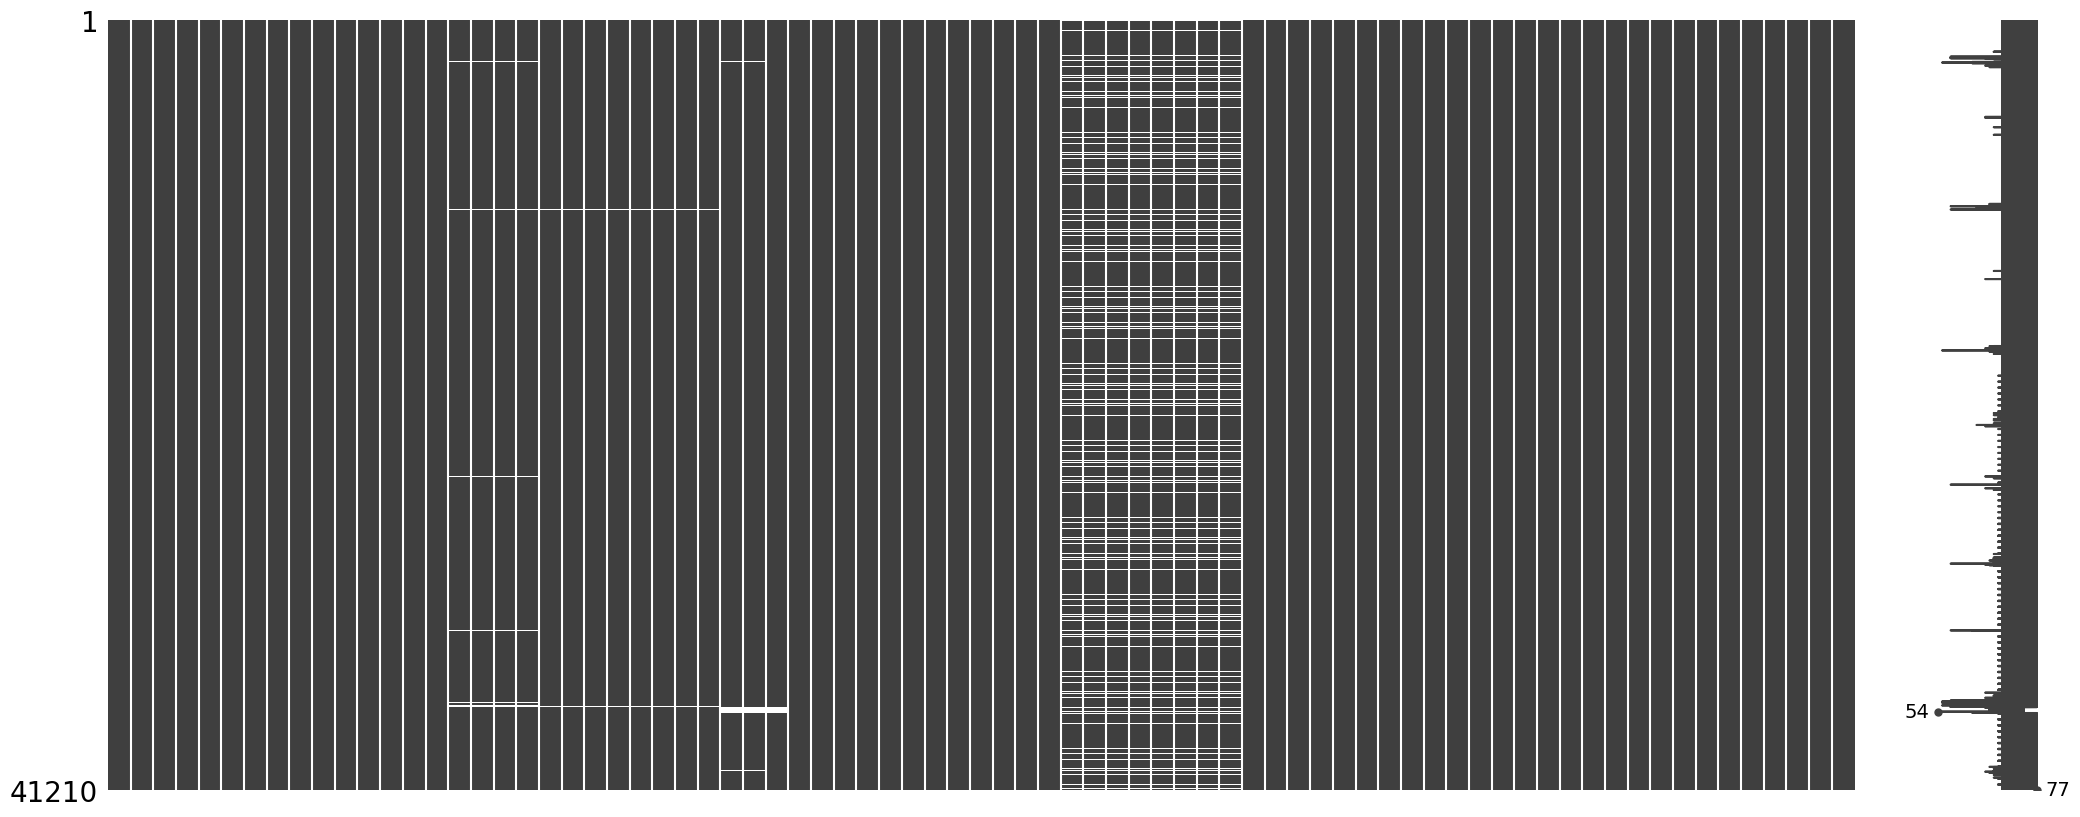

In [12]:
msno.matrix(dataset_final, label_rotation=90)
ax = plt.gca()

In [13]:
dataset_final.drop(columns=['location'], inplace=True)
dataset_final.reset_index(drop=True, inplace=True)
for col in dataset_final.select_dtypes(include='float').columns:
    if dataset_final[col].dropna().apply(float.is_integer).all():
        dataset_final[col] = dataset_final[col].astype('Int64')

In [14]:
dataset_final

,GID0,GID1,GID2,GID3,x,y,dt_prediction,year,month,month_sin,month_cos,dt_weather_acc,year_biovars,year_lc,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_min_prev_month,lst_max_prev_month,rainfall,rainfall_acc_prev_month,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,extreme nord,diamare,bogo,balaza,14.515776,10.786560,2015-01,2015,1,0.500,0.866,2014-12,2014,2014,0.193720,-0.107755,-0.368326,0.107755,0.194397,-0.106597,-0.366073,0.106597,0.012763,0.014083,0.014467,0.014083,25.68,34.58,16.78,16.01,43.30,0.0000,0.0707,39276.65,1226.36,1.93,150.78,348.81,179.77,0.0,4.88,8546.38,700.05,1.44,17.48,12.99,0.22,0.0,11.33,31,36,30,12,12,1,6,7,30.67,24.83,63.68,276.61,53,14,39,29.17,29.33,34.33,28.83,1345,483,0,143.14,1072,0,85,911
1,extreme nord,diamare,bogo,balda,14.724237,10.914551,2015-01,2015,1,0.500,0.866,2014-12,2014,2014,0.168083,-0.119696,-0.352593,0.119696,0.169689,-0.117560,-0.351610,0.117560,0.010680,0.011892,0.011157,0.011892,26.24,35.49,16.99,16.36,45.76,0.0000,0.1057,18291.64,963.16,2.62,156.14,318.51,179.90,0.0,132.00,4472.68,795.26,1.50,10.59,7.15,0.17,0.0,326.39,31,36,30,12,12,1,6,7,31.54,26.42,64.43,304.11,54,13,41,29.67,29.83,35.00,29.33,1228,422,0,140.46,982,0,91,784
2,extreme nord,diamare,bogo,bogo,14.597860,10.743440,2015-01,2015,1,0.500,0.866,2014-12,2014,2014,0.186568,-0.100576,-0.358255,0.100576,0.189237,-0.099525,-0.362545,0.099525,0.010527,0.008578,0.009904,0.008578,25.53,34.59,16.48,16.29,43.22,0.0000,0.0725,31538.78,677.10,4.25,161.02,341.31,179.70,0.0,18.34,2223.42,767.99,1.50,12.02,3.33,0.22,0.0,11.73,31,36,30,12,12,1,6,7,30.08,24.83,63.68,292.20,52,13,39,27.83,29.17,34.17,27.33,1324,475,0,144.61,1070,0,74,701
3,extreme nord,diamare,bogo,borai,14.606980,10.653607,2015-01,2015,1,0.500,0.866,2014-12,2014,2014,0.192535,-0.110211,-0.365544,0.110211,0.191105,-0.111085,-0.367493,0.111085,0.008786,0.009590,0.011213,0.009590,25.28,33.81,16.75,16.75,42.51,0.0000,0.0133,35412.34,801.73,2.50,156.39,340.98,179.71,0.0,32.70,3693.13,560.29,1.52,9.36,2.91,0.19,0.0,63.23,31,36,30,12,12,1,6,7,29.92,24.33,60.83,282.71,52,12,40,27.83,28.83,33.83,27.00,1301,476,0,144.58,1048,0,63,693
4,extreme nord,diamare,bogo,guinggley,14.702740,10.792848,2015-01,2015,1,0.500,0.866,2014-12,2014,2014,0.184092,-0.100503,-0.358690,0.100503,0.181272,-0.101963,-0.357540,0.101963,0.012842,0.013507,0.011516,0.013507,25.77,35.01,16.52,16.63,44.81,0.0000,0.1475,18966.68,1323.61,2.50,157.37,326.72,179.91,0.0,251.95,5392.49,784.41,1.20,5.78,5.71,0.12,0.0,705.96,31,36,30,12,12,1,6,7,30.71,25.08,64.32,279.17,53,14,39,28.17,29.50,34.17,28.17,1268,440,0,142.37,1023,0,180,1023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41205,extreme nord,mayo-tsanaga,roua,midre,13.871290,10.791350,2025-10,2025,10,-0.866,0.500,2025-09,2024,2024,0.409244,-0.003099,-0.396868,0.003099,0.419617,0.016663,-0.401062,-0.016663,0.013638,0.013470,0.008699,0.013470,25.92,30.08,21.72,19.86,30.58,0.0317,9.2267,108691.34,1322.49,4.33,172.99,759.46,179.21,0.0,62.92,2224.04,1215.46,3.21,70.29,46.80,2.81,0.0,93.52,31,36,30,12,12,3,5,8,27.67,20.67,62.63,282.31,47,14,33,26.50,25.33,31.50,25.33,1941,597,0,135.39,1464,1,61,158
41206,extreme nord,mayo-tsanaga,roua,ndimche,13.968570,10.827287,2025-10,2025,10,-0.866,0.500,2025-09,2024,2024,0.

In [15]:
dataset_final.to_csv(f'../../data/{REGION}/CM_{REGION}_Test_Dataset_2015-2025.csv', index=False,  encoding=enc)